# Portfolio Analysis - Stock Selection Methods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

returns_df = pd.read_excel("daily_returns.xlsx")
categories_df = pd.read_excel("stock_categories.xlsx")

returns_df[returns_df.columns.difference(['Date'])] = returns_df[returns_df.columns.difference(['Date'])] / 100

print(f"Data loaded: {len(returns_df)} days")
print(f"Stocks: {len(returns_df.columns) - 1}")

sectors = categories_df.groupby("Category")["Symbol"].apply(list).to_dict()
corr_matrix_full = returns_df.drop(columns=["Date"]).corr()
stock_returns = returns_df.drop(columns=["Date"])

risk_free_rate = 0.065
trading_days = 252

mean_returns = stock_returns.mean() * trading_days
std_returns = stock_returns.std() * np.sqrt(trading_days)
sharpe_ratios = (mean_returns - risk_free_rate) / std_returns

Data loaded: 739 days
Stocks: 30


## Optimization Function

In [2]:
import scipy.optimize as sco

def optimize_portfolio(selected_stocks, stock_returns_df, method_name):
    selected_returns = stock_returns_df[selected_stocks]
    
    # Data is already in decimal form
    mean_daily_returns = selected_returns.mean()
    cov_matrix_daily = selected_returns.cov()
    
    annual_returns = mean_daily_returns * trading_days
    annual_cov = cov_matrix_daily * trading_days
    
    # ============================================================
    # Monte Carlo simulation
    np.random.seed(42)
    num_portfolios = 10000
    mc_results = np.zeros((3, num_portfolios))
    weights_record = []
    
    for i in range(num_portfolios):
        weights = np.random.random(len(selected_stocks))
        weights /= np.sum(weights)
        weights_record.append(weights)
        
        portfolio_return = np.dot(weights, annual_returns)
        portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights)))
        
        mc_results[0, i] = portfolio_return
        mc_results[1, i] = portfolio_std_dev
        mc_results[2, i] = (portfolio_return - risk_free_rate) / portfolio_std_dev
    
    mc_max_sharpe_idx = np.argmax(mc_results[2])
    mc_max_sharpe_w = weights_record[mc_max_sharpe_idx]
    
    mc_min_vol_idx = np.argmin(mc_results[1])
    mc_min_vol_w = weights_record[mc_min_vol_idx]
    
    # ============================================================
    # METHOD 2: TRUE MATHEMATICAL OPTIMIZATION (scipy)
    # Mathematical optimization
    num_assets = len(selected_stocks)
    
    def portfolio_performance(weights):
        returns = np.sum(annual_returns * weights)
        std = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights)))
        return returns, std
    
    def neg_sharpe_ratio(weights):
        p_ret, p_std = portfolio_performance(weights)
        return -(p_ret - risk_free_rate) / p_std
    
    def portfolio_volatility(weights):
        return portfolio_performance(weights)[1]
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    init_guess = num_assets * [1. / num_assets]
    
    # Optimize for Max Sharpe
    opt_sharpe = sco.minimize(neg_sharpe_ratio, init_guess,
                              args=(),
                              method='SLSQP', 
                              bounds=bounds, 
                              constraints=constraints)
    
    opt_sharpe_weights = opt_sharpe.x
    opt_ret, opt_vol = portfolio_performance(opt_sharpe_weights)
    opt_sharpe_ratio = (opt_ret - risk_free_rate) / opt_vol
    
    # Optimize for Min Variance (GMV)
    opt_var = sco.minimize(portfolio_volatility, init_guess,
                           args=(),
                           method='SLSQP', 
                           bounds=bounds, 
                           constraints=constraints)
    
    opt_gmv_weights = opt_var.x
    opt_gmv_ret, opt_gmv_vol = portfolio_performance(opt_gmv_weights)
    opt_gmv_sharpe = (opt_gmv_ret - risk_free_rate) / opt_gmv_vol
    
    return {
        'method': method_name,
        'stocks': selected_stocks,
        # Monte Carlo results
        'mc_results': mc_results,
        'results': mc_results,  # Backward compatibility
        'mc_max_sharpe_idx': mc_max_sharpe_idx,
        'max_sharpe_idx': mc_max_sharpe_idx,  # Backward compatibility
        'mc_min_vol_idx': mc_min_vol_idx,
        'min_vol_idx': mc_min_vol_idx,  # Backward compatibility
        'mc_gmv_weights': mc_min_vol_w,
        'mc_max_sharpe_weights': mc_max_sharpe_w,
        'mc_gmv_sharpe': mc_results[2, mc_min_vol_idx],
        'mc_max_sharpe': mc_results[2, mc_max_sharpe_idx],
        'mc_gmv_return': mc_results[0, mc_min_vol_idx],
        'mc_max_sharpe_return': mc_results[0, mc_max_sharpe_idx],
        'mc_gmv_vol': mc_results[1, mc_min_vol_idx],
        'mc_max_sharpe_vol': mc_results[1, mc_max_sharpe_idx],
        # Optimized results
        'opt_gmv_weights': opt_gmv_weights,
        'opt_max_sharpe_weights': opt_sharpe_weights,
        'opt_gmv_sharpe': opt_gmv_sharpe,
        'opt_max_sharpe': opt_sharpe_ratio,
        'opt_gmv_return': opt_gmv_ret,
        'opt_max_sharpe_return': opt_ret,
        'opt_gmv_vol': opt_gmv_vol,
        'opt_max_sharpe_vol': opt_vol,
        'returns': selected_returns

    }
print("Optimization function defined (Monte Carlo + True Optimization)")


Optimization function defined (Monte Carlo + True Optimization)


## Method 1: Lowest Correlation

In [3]:
print("Method 1: Lowest Correlation Selection")
print("=" * 60)

corr_stocks = []
for sector, stocks in sectors.items():
    avg_corrs = corr_matrix_full[stocks].mean(axis=0)
    best_stock = avg_corrs.idxmin()
    corr_stocks.append(best_stock)
    print(f"{sector:25s}: {best_stock:15s} (avg corr: {avg_corrs[best_stock]:.4f})")

print(f"\nSelected {len(corr_stocks)} stocks using Lowest Correlation")
method1 = optimize_portfolio(corr_stocks, returns_df, "Lowest Correlation")

Method 1: Lowest Correlation Selection
Automobiles              : BAJAJ-AUTO      (avg corr: 0.2496)
Banking & Finance        : HDFCBANK        (avg corr: 0.2532)
Construction/Infra       : ADANIPORTS      (avg corr: 0.3013)
Consumer Goods           : HINDUNILVR      (avg corr: 0.1584)
Energy & Power           : POWERGRID       (avg corr: 0.2909)
Information Tech         : TCS             (avg corr: 0.2342)
Metals & Mining          : HINDALCO        (avg corr: 0.2952)
Pharmaceuticals          : CIPLA           (avg corr: 0.1889)
Retail/E-commerce        : DMART           (avg corr: 0.1663)
Telecommunications       : INDUSTOWER      (avg corr: 0.2439)

Selected 10 stocks using Lowest Correlation


## Method 4: HRP

In [4]:
print("Method 4: HRP")
print("=" * 60)

hrp_stocks = []
for sector, stocks in sectors.items():
    if len(stocks) == 1:
        hrp_stocks.append(stocks[0])
        print(f"{sector:25s}: {stocks[0]:15s} (only stock in sector)")
    else:
        sector_corr = corr_matrix_full.loc[stocks, stocks]
        dist_matrix = np.sqrt(0.5 * (1 - sector_corr))
        dist_condensed = squareform(dist_matrix, checks=False)
        linkage_matrix = linkage(dist_condensed, method='ward')
        avg_distances = dist_matrix.sum(axis=0) / (len(stocks) - 1)
        best_stock = avg_distances.idxmax()
        hrp_stocks.append(best_stock)
        print(f"{sector:25s}: {best_stock:15s} (avg distance: {avg_distances[best_stock]:.4f})")

print(f"\n Selected {len(hrp_stocks)} stocks using HRP")
method4 = optimize_portfolio(hrp_stocks, returns_df, "Hierarchical Risk Parity")

Method 4: HRP
Automobiles              : BAJAJ-AUTO      (avg distance: 0.5647)
Banking & Finance        : SBIN            (avg distance: 0.5501)
Construction/Infra       : ULTRACEMCO      (avg distance: 0.5625)
Consumer Goods           : ITC             (avg distance: 0.5782)
Energy & Power           : RELIANCE        (avg distance: 0.5464)
Information Tech         : HCLTECH         (avg distance: 0.4114)
Metals & Mining          : HINDALCO        (avg distance: 0.4232)
Pharmaceuticals          : SUNPHARMA       (avg distance: 0.5483)
Retail/E-commerce        : TRENT           (avg distance: 0.6242)
Telecommunications       : BHARTIARTL      (avg distance: 0.6009)

 Selected 10 stocks using HRP


## Performance Summary

In [5]:
all_methods = [method1, method4]

print("\n" + "=" * 80)
print("MONTE CARLO RESULTS")
print("=" * 80)
mc_data = []
for m in all_methods:
    mc_data.append({
        'Method': f"{m['method']} - GMV",
        'Return': f"{m['mc_gmv_return']:.2%}",
        'Volatility': f"{m['mc_gmv_vol']:.2%}",
        'Sharpe': f"{m['mc_gmv_sharpe']:.4f}"
    })
    mc_data.append({
        'Method': f"{m['method']} - Max Sharpe",
        'Return': f"{m['mc_max_sharpe_return']:.2%}",
        'Volatility': f"{m['mc_max_sharpe_vol']:.2%}",
        'Sharpe': f"{m['mc_max_sharpe']:.4f}"
    })

mc_df = pd.DataFrame(mc_data)
print("\n" + mc_df.to_string(index=False))

# Optimized Results
print("\n" + "=" * 80)
print("OPTIMIZATION RESULTS")
print("=" * 80)
opt_data = []
for m in all_methods:
    opt_data.append({
        'Method': f"{m['method']} - GMV",
        'Return': f"{m['opt_gmv_return']:.2%}",
        'Volatility': f"{m['opt_gmv_vol']:.2%}",
        'Sharpe': f"{m['opt_gmv_sharpe']:.4f}"
    })
    opt_data.append({
        'Method': f"{m['method']} - Max Sharpe",
        'Return': f"{m['opt_max_sharpe_return']:.2%}",
        'Volatility': f"{m['opt_max_sharpe_vol']:.2%}",
        'Sharpe': f"{m['opt_max_sharpe']:.4f}"
    })

opt_df = pd.DataFrame(opt_data)
print("\n" + opt_df.to_string(index=False))

# Best performers
print("\n" + "=" * 80)
print("BEST PORTFOLIOS")
print("=" * 80)

all_mc_sharpes = {}
all_opt_sharpes = {}
for m in all_methods:
    all_mc_sharpes[f"{m['method']} - GMV"] = m['mc_gmv_sharpe']
    all_mc_sharpes[f"{m['method']} - Max Sharpe"] = m['mc_max_sharpe']
    all_opt_sharpes[f"{m['method']} - GMV"] = m['opt_gmv_sharpe']
    all_opt_sharpes[f"{m['method']} - Max Sharpe"] = m['opt_max_sharpe']

mc_best = max(all_mc_sharpes, key=all_mc_sharpes.get)
opt_best = max(all_opt_sharpes, key=all_opt_sharpes.get)

print(f"\nMonte Carlo Best: {mc_best} (Sharpe: {all_mc_sharpes[mc_best]:.4f})")
print(f"Optimization Best: {opt_best} (Sharpe: {all_opt_sharpes[opt_best]:.4f})")


MONTE CARLO RESULTS

                               Method Return Volatility Sharpe
             Lowest Correlation - GMV 11.35%     11.04% 0.4388
      Lowest Correlation - Max Sharpe 31.32%     16.85% 1.4725
       Hierarchical Risk Parity - GMV 20.76%     11.83% 1.2058
Hierarchical Risk Parity - Max Sharpe 32.29%     14.60% 1.7668

OPTIMIZATION RESULTS

                               Method Return Volatility Sharpe
             Lowest Correlation - GMV  9.01%     10.74% 0.2338
      Lowest Correlation - Max Sharpe 38.71%     20.13% 1.6001
       Hierarchical Risk Parity - GMV 18.88%     11.62% 1.0652
Hierarchical Risk Parity - Max Sharpe 35.14%     15.64% 1.8308

BEST PORTFOLIOS

Monte Carlo Best: Hierarchical Risk Parity - Max Sharpe (Sharpe: 1.7668)
Optimization Best: Hierarchical Risk Parity - Max Sharpe (Sharpe: 1.8308)


## Detailed Comparison

In [6]:
print("\n" + "=" * 80)
print("DETAILED COMPARISON")
print("=" * 80)

print(f"\n{'METHOD':<35} {'MC GMV':<12} {'MC MaxSh':<12} {'OPT GMV':<12} {'OPT MaxSh':<12}")
print("-" * 90)

for i, m in enumerate(all_methods, 1):
    print(f"{i}. {m['method']:<32} "
          f"{m['mc_gmv_sharpe']:<12.4f} {m['mc_max_sharpe']:<12.4f} "
          f"{m['opt_gmv_sharpe']:<12.4f} {m['opt_max_sharpe']:<12.4f}")

print("\n" + "=" * 90)
print("BREAKDOWN BY METHOD")
print("=" * 90)

for i, m in enumerate(all_methods, 1):
    print(f"\n{i}. {m['method'].upper()}")
    print("-" * 90)
    print(f"{'Portfolio':<20} {'Approach':<15} {'Return':<15} {'Vol':<15} {'Sharpe':<15}")
    print("-" * 90)
    print(f"{'GMV':<20} {'MC':<15} "
          f"{m['mc_gmv_return']:<15.2%} {m['mc_gmv_vol']:<15.2%} {m['mc_gmv_sharpe']:<15.4f}")
    print(f"{'GMV':<20} {'Opt':<15} "
          f"{m['opt_gmv_return']:<15.2%} {m['opt_gmv_vol']:<15.2%} {m['opt_gmv_sharpe']:<15.4f}")
    print(f"{'Max Sharpe':<20} {'MC':<15} "
          f"{m['mc_max_sharpe_return']:<15.2%} {m['mc_max_sharpe_vol']:<15.2%} {m['mc_max_sharpe']:<15.4f}")
    print(f"{'Max Sharpe':<20} {'Opt':<15} "
          f"{m['opt_max_sharpe_return']:<15.2%} {m['opt_max_sharpe_vol']:<15.2%} {m['opt_max_sharpe']:<15.4f}")

print("\n" + "=" * 80)
print("OVERALL WINNERS")
print("=" * 80)

print("\nBest Monte Carlo: {}".format(mc_best))
print("Sharpe: {:.4f}".format(all_mc_sharpes[mc_best]))

print("\nBest Optimized: {}".format(opt_best))
print("Sharpe: {:.4f}".format(all_opt_sharpes[opt_best]))

improvement = all_opt_sharpes[opt_best] - all_mc_sharpes[mc_best]
print(f"\nImprovement: {improvement:.4f}")


DETAILED COMPARISON

METHOD                              MC GMV       MC MaxSh     OPT GMV      OPT MaxSh   
------------------------------------------------------------------------------------------
1. Lowest Correlation               0.4388       1.4725       0.2338       1.6001      
2. Hierarchical Risk Parity         1.2058       1.7668       1.0652       1.8308      

BREAKDOWN BY METHOD

1. LOWEST CORRELATION
------------------------------------------------------------------------------------------
Portfolio            Approach        Return          Vol             Sharpe         
------------------------------------------------------------------------------------------
GMV                  MC              11.35%          11.04%          0.4388         
GMV                  Opt             9.01%           10.74%          0.2338         
Max Sharpe           MC              31.32%          16.85%          1.4725         
Max Sharpe           Opt             38.71%          20.1

## Stock Selections

In [7]:
print("\n" + "=" * 80)
print("Stock Selections")
print("=" * 80)

selection_df = pd.DataFrame({
    'Sector': list(sectors.keys()),
    'Method 1 (Low Corr)': corr_stocks,
    'Method 2 (HRP)': hrp_stocks
})

print("\n" + selection_df.to_string(index=False))

print("\n" + "=" * 80)
print("Overlaps")
print("=" * 80)
methods_stocks = [
    ('Low Corr', set(corr_stocks)),
    ('HRP', set(hrp_stocks))
]

for i, (name1, stocks1) in enumerate(methods_stocks):
    for name2, stocks2 in methods_stocks[i+1:]:
        overlap = len(stocks1 & stocks2)
        print(f"{name1:12s} vs {name2:12s}: {overlap}/{len(corr_stocks)} stocks in common ({overlap/len(corr_stocks)*100:.1f}%)")


Stock Selections

            Sector Method 1 (Low Corr) Method 2 (HRP)
       Automobiles          BAJAJ-AUTO     BAJAJ-AUTO
 Banking & Finance            HDFCBANK           SBIN
Construction/Infra          ADANIPORTS     ULTRACEMCO
    Consumer Goods          HINDUNILVR            ITC
    Energy & Power           POWERGRID       RELIANCE
  Information Tech                 TCS        HCLTECH
   Metals & Mining            HINDALCO       HINDALCO
   Pharmaceuticals               CIPLA      SUNPHARMA
 Retail/E-commerce               DMART          TRENT
Telecommunications          INDUSTOWER     BHARTIARTL

Overlaps
Low Corr     vs HRP         : 2/10 stocks in common (20.0%)


## Portfolio Weights

In [8]:
for m in all_methods:
    print("\n" + "=" * 80)
    print(f"{m['method']}")
    print("=" * 80)
    
    # Combined weights table
    weights_df = pd.DataFrame({
        'Stock': m['stocks'],
        'MC GMV': [f"{w:.2%}" for w in m['mc_gmv_weights']],
        'MC Max Sharpe': [f"{w:.2%}" for w in m['mc_max_sharpe_weights']],
        'Opt GMV': [f"{w:.2%}" for w in m['opt_gmv_weights']],
        'Opt Max Sharpe': [f"{w:.2%}" for w in m['opt_max_sharpe_weights']]
    })
    print("\n" + weights_df.to_string(index=False))


Lowest Correlation

     Stock MC GMV MC Max Sharpe Opt GMV Opt Max Sharpe
BAJAJ-AUTO 11.22%        27.11%   7.76%         48.18%
  HDFCBANK 24.54%         4.30%  22.24%          0.00%
ADANIPORTS  1.88%        14.02%   0.00%         16.56%
HINDUNILVR 12.72%         1.03%  23.16%          0.00%
 POWERGRID  4.11%         1.55%   4.94%          0.00%
       TCS 20.69%         1.58%  18.05%          0.00%
  HINDALCO  0.79%        14.44%   1.09%         12.00%
     CIPLA 11.62%        17.30%  13.86%          0.00%
     DMART 10.07%         0.10%   7.81%          0.00%
INDUSTOWER  2.35%        18.58%   1.09%         23.26%

Hierarchical Risk Parity

     Stock MC GMV MC Max Sharpe Opt GMV Opt Max Sharpe
BAJAJ-AUTO  9.10%        28.80%   7.00%         24.58%
      SBIN  8.49%        17.15%   8.40%         16.19%
ULTRACEMCO  8.16%         5.08%  10.38%          0.00%
       ITC 22.23%         0.77%  25.46%          0.00%
  RELIANCE  1.17%         0.64%   2.61%          0.00%
   HCLTECH 10.72%

## Weight Attribution: GMV vs Maximum Sharpe

In [9]:
print("\n" + "=" * 100)
print("WEIGHT ATTRIBUTION: GMV vs MAXIMUM SHARPE PORTFOLIOS")
print("=" * 100)

for i, m in enumerate(all_methods, 1):
    print(f"\n{i}. {m['method'].upper()}")
    print("-" * 100)
    
    # Create weight attribution table
    weight_data = []
    for stock in m['stocks']:
        idx = m['stocks'].index(stock)
        weight_data.append({
            'Stock': stock,
            'GMV Weight (Opt)': f"{m['opt_gmv_weights'][idx]:.2%}",
            'Max Sharpe Weight (Opt)': f"{m['opt_max_sharpe_weights'][idx]:.2%}",
            'Difference': f"{(m['opt_max_sharpe_weights'][idx] - m['opt_gmv_weights'][idx]):.2%}"
        })
    
    weight_df = pd.DataFrame(weight_data)
    weight_df = weight_df.sort_values('Max Sharpe Weight (Opt)', 
                                       key=lambda x: x.str.rstrip('%').astype(float), 
                                       ascending=False)
    
    print("\n" + weight_df.to_string(index=False))
    
    # Summary statistics
    gmv_weights = m['opt_gmv_weights']
    sharpe_weights = m['opt_max_sharpe_weights']
    
    print(f"\nConcentration Metrics:")
    print(f"  GMV Portfolio:        Top 3 holdings = {sum(sorted(gmv_weights, reverse=True)[:3]):.2%}")
    print(f"  Max Sharpe Portfolio: Top 3 holdings = {sum(sorted(sharpe_weights, reverse=True)[:3]):.2%}")
    print(f"  GMV Herfindahl Index:        {sum(w**2 for w in gmv_weights):.4f}")
    print(f"  Max Sharpe Herfindahl Index: {sum(w**2 for w in sharpe_weights):.4f}")

print("\n" + "=" * 100)


WEIGHT ATTRIBUTION: GMV vs MAXIMUM SHARPE PORTFOLIOS

1. LOWEST CORRELATION
----------------------------------------------------------------------------------------------------

     Stock GMV Weight (Opt) Max Sharpe Weight (Opt) Difference
BAJAJ-AUTO            7.76%                  48.18%     40.42%
INDUSTOWER            1.09%                  23.26%     22.17%
ADANIPORTS            0.00%                  16.56%     16.56%
  HINDALCO            1.09%                  12.00%     10.91%
  HDFCBANK           22.24%                   0.00%    -22.24%
HINDUNILVR           23.16%                   0.00%    -23.16%
       TCS           18.05%                   0.00%    -18.05%
 POWERGRID            4.94%                   0.00%     -4.94%
     CIPLA           13.86%                   0.00%    -13.86%
     DMART            7.81%                   0.00%     -7.81%

Concentration Metrics:
  GMV Portfolio:        Top 3 holdings = 63.46%
  Max Sharpe Portfolio: Top 3 holdings = 88.00%
  GMV He

In [10]:
import os

# Create output folder for images
output_folder = 'portfolio_plots'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")
else:
    print(f"Folder already exists: {output_folder}")

Folder already exists: portfolio_plots


## Efficient Frontiers

Saved: portfolio_plots/efficient_frontier_method1.png


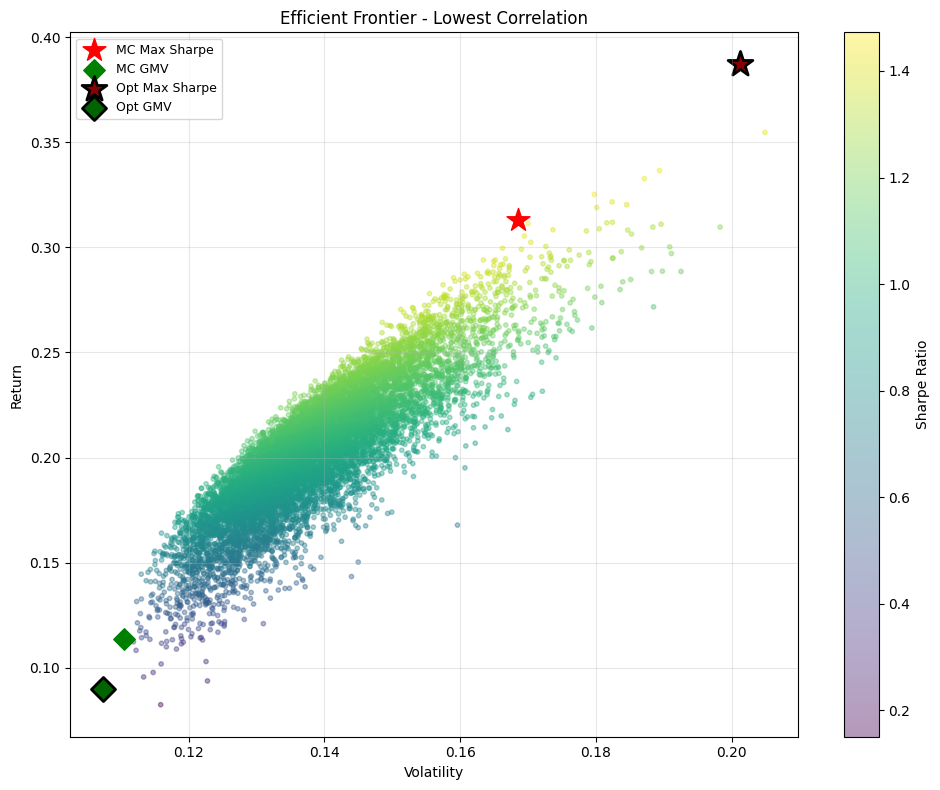

Saved: portfolio_plots/efficient_frontier_method2.png


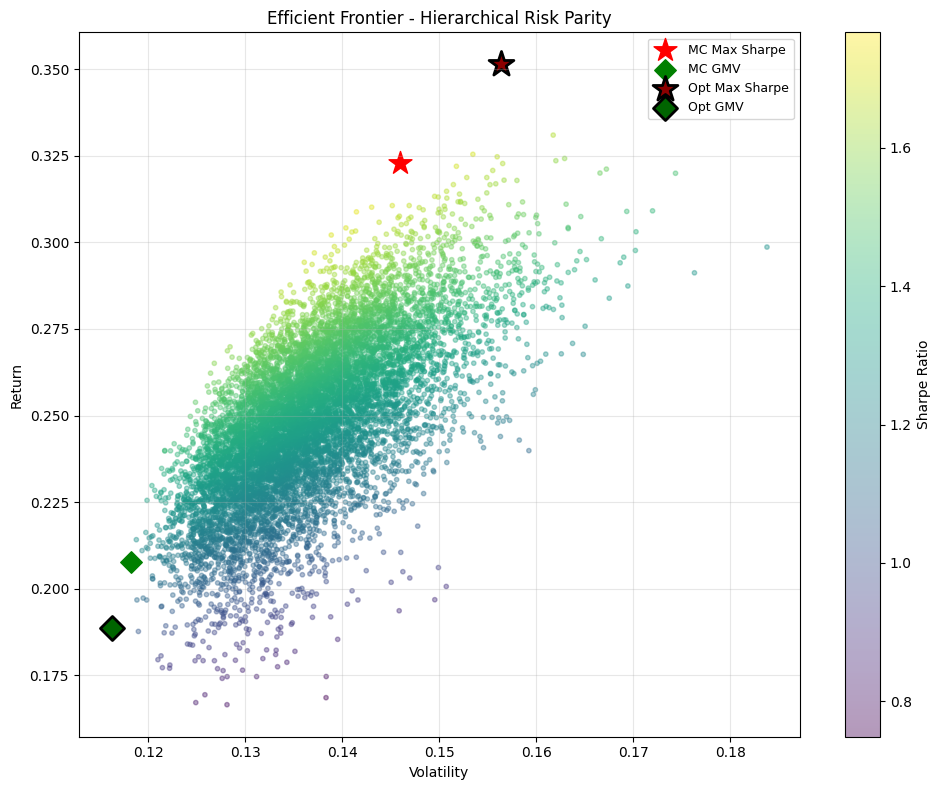

In [11]:
for idx, m in enumerate(all_methods, 1):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sc = ax.scatter(
        m['results'][1, :],
        m['results'][0, :],
        c=m['results'][2, :],
        cmap='viridis',
        s=10,
        alpha=0.4
    )
    
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Sharpe Ratio')
    
    ax.scatter(
        m['results'][1, m['max_sharpe_idx']],
        m['results'][0, m['max_sharpe_idx']],
        marker='*',
        color='red',
        s=300,
        label=f"MC Max Sharpe"
    )
    
    ax.scatter(
        m['results'][1, m['min_vol_idx']],
        m['results'][0, m['min_vol_idx']],
        marker='D',
        color='green',
        s=120,
        label=f"MC GMV"
    )
    
    ax.scatter(
        m['opt_max_sharpe_vol'],
        m['opt_max_sharpe_return'],
        marker='*',
        color='darkred',
        s=350,
        edgecolors='black',
        linewidths=2,
        label=f"Opt Max Sharpe"
    )
    
    ax.scatter(
        m['opt_gmv_vol'],
        m['opt_gmv_return'],
        marker='D',
        color='darkgreen',
        s=150,
        edgecolors='black',
        linewidths=2,
        label=f"Opt GMV"
    )
    
    ax.set_xlabel('Volatility')
    ax.set_ylabel('Return')
    ax.set_title(f"Efficient Frontier - {m['method']}")
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    filename = f"{output_folder}/efficient_frontier_method{idx}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"Saved: {filename}")
    plt.show()
    plt.close()

## Correlation Heatmaps

Saved: portfolio_plots/correlation_matrix_method1.png


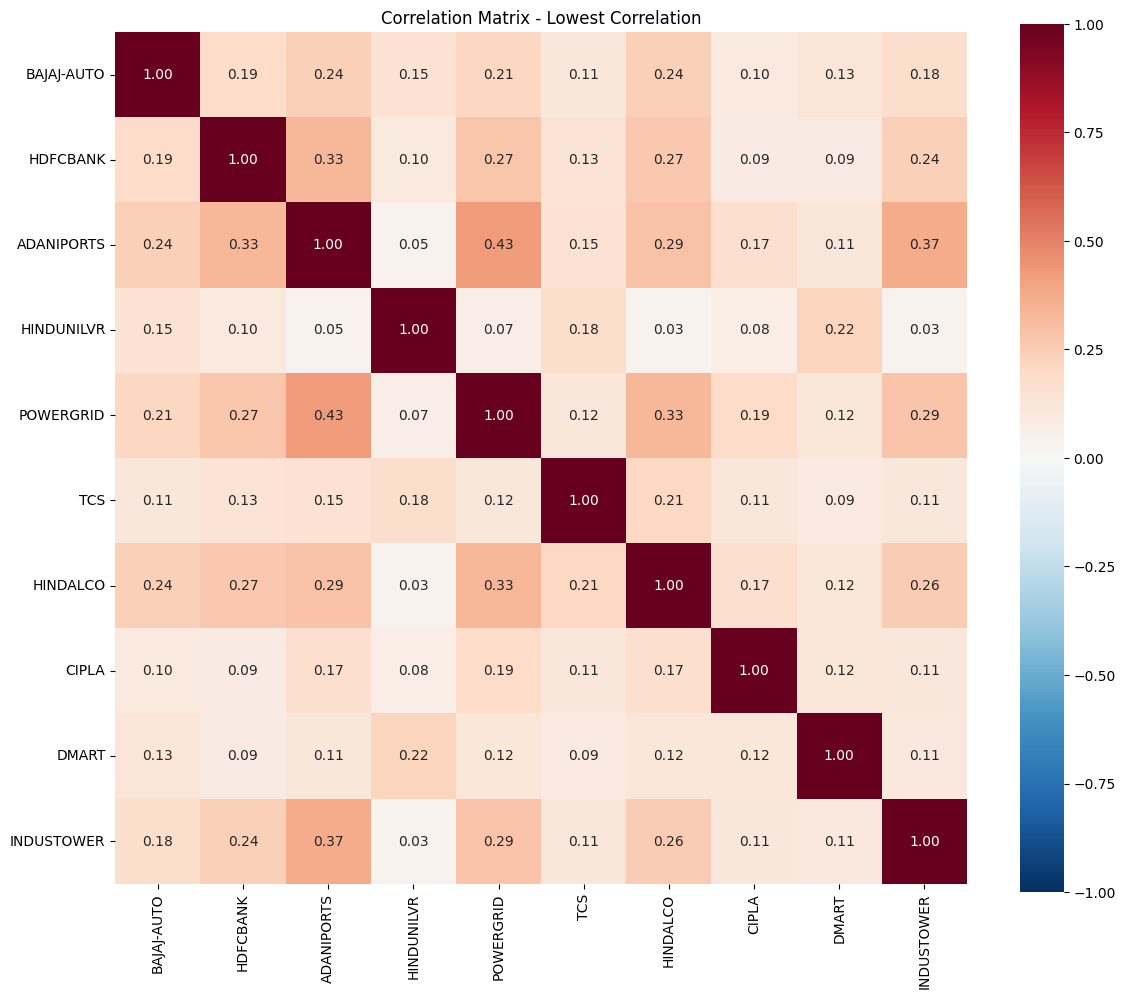

Saved: portfolio_plots/correlation_matrix_method2.png


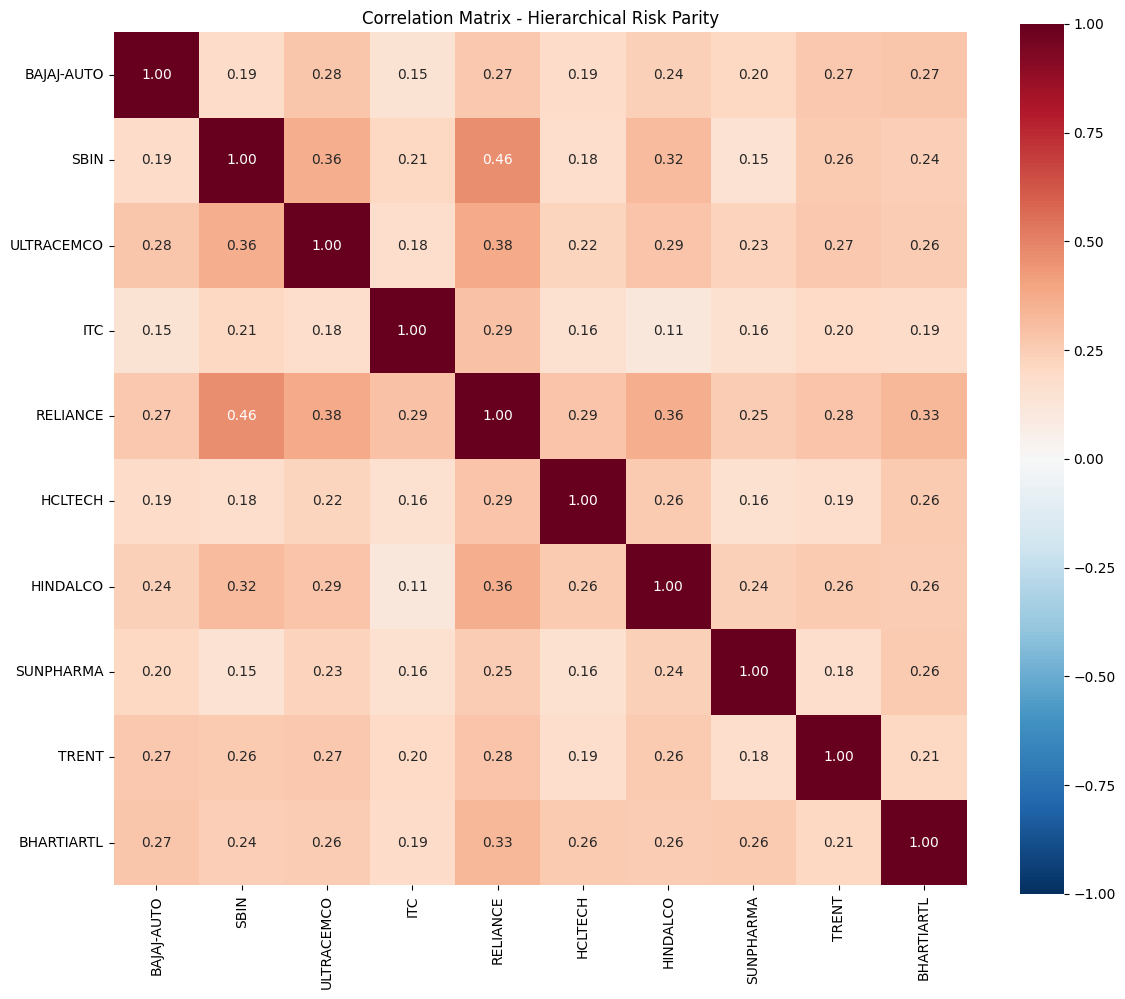

In [12]:
for idx, m in enumerate(all_methods, 1):
    fig, ax = plt.subplots(figsize=(12, 10))
    corr = m['returns'].corr()
    
    sns.heatmap(
        corr,
        annot=True,
        cmap='RdBu_r',
        center=0,
        fmt='.2f',
        square=True,
        ax=ax,
        vmin=-1,
        vmax=1
    )
    
    ax.set_title(f"Correlation Matrix - {m['method']}")
    
    plt.tight_layout()
    filename = f"{output_folder}/correlation_matrix_method{idx}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"Saved: {filename}")
    plt.show()
    plt.close()

## Performance Charts

Saved: portfolio_plots/performance_comparison.png


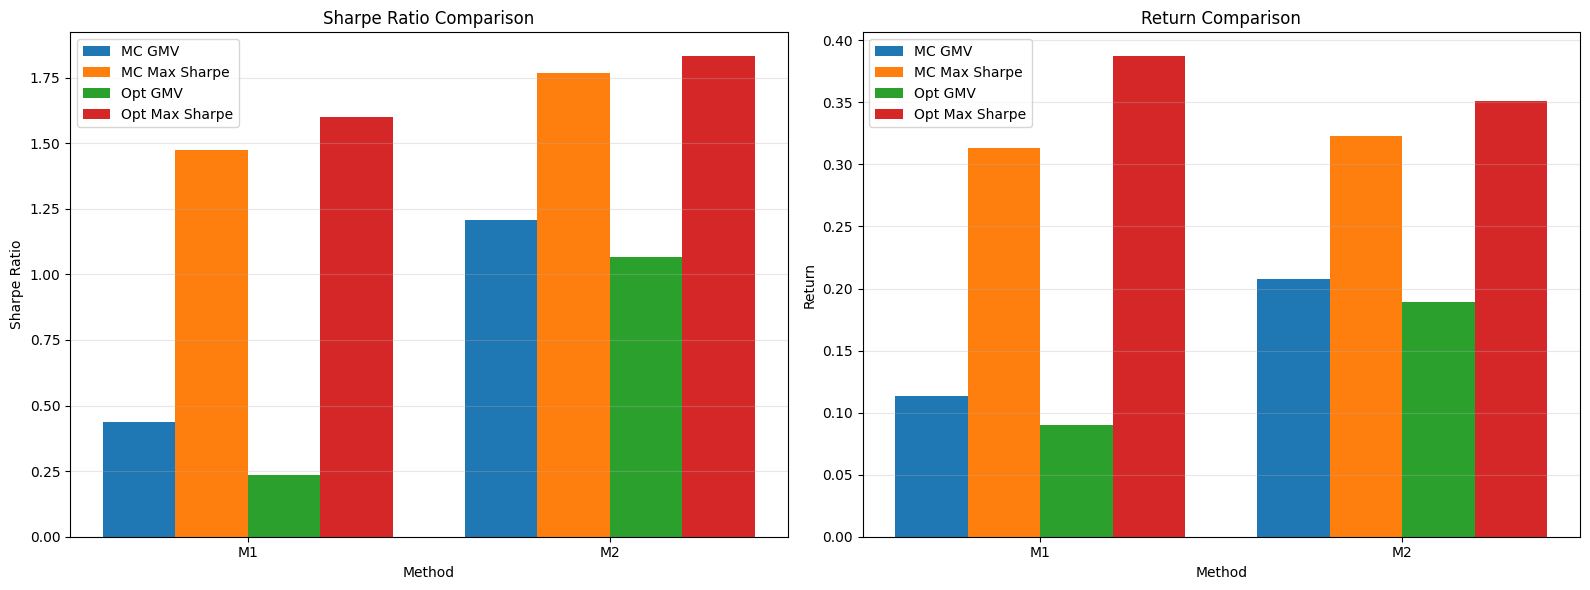

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

methods = [m['method'] for m in all_methods]

mc_gmv_sharpes = [m['mc_gmv_sharpe'] for m in all_methods]
mc_max_sharpes = [m['mc_max_sharpe'] for m in all_methods]
opt_gmv_sharpes = [m['opt_gmv_sharpe'] for m in all_methods]
opt_max_sharpes = [m['opt_max_sharpe'] for m in all_methods]

x = np.arange(len(methods))
width = 0.2

bars1 = ax1.bar(x - 1.5*width, mc_gmv_sharpes, width, label='MC GMV')
bars2 = ax1.bar(x - 0.5*width, mc_max_sharpes, width, label='MC Max Sharpe')
bars3 = ax1.bar(x + 0.5*width, opt_gmv_sharpes, width, label='Opt GMV')
bars4 = ax1.bar(x + 1.5*width, opt_max_sharpes, width, label='Opt Max Sharpe')

ax1.set_xlabel('Method')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_title('Sharpe Ratio Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels([f"M{i+1}" for i in range(len(methods))])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

mc_gmv_returns = [m['mc_gmv_return'] for m in all_methods]
mc_max_returns = [m['mc_max_sharpe_return'] for m in all_methods]
opt_gmv_returns = [m['opt_gmv_return'] for m in all_methods]
opt_max_returns = [m['opt_max_sharpe_return'] for m in all_methods]

bars5 = ax2.bar(x - 1.5*width, mc_gmv_returns, width, label='MC GMV')
bars6 = ax2.bar(x - 0.5*width, mc_max_returns, width, label='MC Max Sharpe')
bars7 = ax2.bar(x + 0.5*width, opt_gmv_returns, width, label='Opt GMV')
bars8 = ax2.bar(x + 1.5*width, opt_max_returns, width, label='Opt Max Sharpe')

ax2.set_xlabel('Method')
ax2.set_ylabel('Return')
ax2.set_title('Return Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels([f"M{i+1}" for i in range(len(methods))])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
filename = f"{output_folder}/performance_comparison.png"
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f"Saved: {filename}")
plt.show()
plt.close()

## Summary

In [ ]:
print("\n" + "=" * 80)
print("Summary")
print("=" * 80)

print("\nMethods:")
print("1. Lowest Correlation: Minimum average correlation")
print("2. HRP: Hierarchical clustering")

print("\n" + "=" * 110)
print("MONTE CARLO RESULTS (10,000 Random Simulations):")
print("=" * 110)
for i, m in enumerate(all_methods, 1):
    print(f"\nMethod {i}: {m['method']}")
    print(f"  GMV Portfolio:        Sharpe = {m['mc_gmv_sharpe']:.4f}  (Return: {m['mc_gmv_return']:.2%}, Vol: {m['mc_gmv_vol']:.2%})")
    print(f"  Max Sharpe Portfolio: Sharpe = {m['mc_max_sharpe']:.4f}  (Return: {m['mc_max_sharpe_return']:.2%}, Vol: {m['mc_max_sharpe_vol']:.2%})")

print("\n" + "=" * 110)
print("OPTIMIZED RESULTS (Mathematical Optimization via scipy):")
print("=" * 110)
for i, m in enumerate(all_methods, 1):
    print(f"\nMethod {i}: {m['method']}")
    print(f"  GMV Portfolio:        Sharpe = {m['opt_gmv_sharpe']:.4f}  (Return: {m['opt_gmv_return']:.2%}, Vol: {m['opt_gmv_vol']:.2%})")
    print(f"  Max Sharpe Portfolio: Sharpe = {m['opt_max_sharpe']:.4f}  (Return: {m['opt_max_sharpe_return']:.2%}, Vol: {m['opt_max_sharpe_vol']:.2%})")

print("\n" + "=" * 110)
print("OVERALL WINNERS:")
print("=" * 110)

# Find best MC
all_mc_sharpes = {}
for m in all_methods:
    all_mc_sharpes[f"{m['method']} - GMV"] = m['mc_gmv_sharpe']
    all_mc_sharpes[f"{m['method']} - Max Sharpe"] = m['mc_max_sharpe']
mc_best = max(all_mc_sharpes, key=all_mc_sharpes.get)

# Find best Optimized
all_opt_sharpes = {}
for m in all_methods:
    all_opt_sharpes[f"{m['method']} - GMV"] = m['opt_gmv_sharpe']
    all_opt_sharpes[f"{m['method']} - Max Sharpe"] = m['opt_max_sharpe']
opt_best = max(all_opt_sharpes, key=all_opt_sharpes.get)

print(f"\nBest Monte Carlo Portfolio:  {mc_best}")
print(f"   Sharpe Ratio: {all_mc_sharpes[mc_best]:.4f}")

print(f"\nBest Optimized Portfolio:    {opt_best}")
print(f"   Sharpe Ratio: {all_opt_sharpes[opt_best]:.4f}")

improvement = all_opt_sharpes[opt_best] - all_mc_sharpes[mc_best]
print(f"\nOptimization vs Monte Carlo Improvement: {improvement:+.4f} ({improvement/all_mc_sharpes[mc_best]*100:+.2f}%)")


Summary

Methods:
1. Lowest Correlation: Minimum average correlation
2. Hybrid: Balance of correlation and Sharpe ratio
3. Max Sharpe: Highest Sharpe ratio
4. HRP: Hierarchical clustering

MONTE CARLO RESULTS (10,000 Random Simulations):

Method 1: Lowest Correlation
  GMV Portfolio:        Sharpe = 0.4388  (Return: 11.35%, Vol: 11.04%)
  Max Sharpe Portfolio: Sharpe = 1.4725  (Return: 31.32%, Vol: 16.85%)

Method 2: Hierarchical Risk Parity
  GMV Portfolio:        Sharpe = 1.2058  (Return: 20.76%, Vol: 11.83%)
  Max Sharpe Portfolio: Sharpe = 1.7668  (Return: 32.29%, Vol: 14.60%)

OPTIMIZED RESULTS (Mathematical Optimization via scipy):

Method 1: Lowest Correlation
  GMV Portfolio:        Sharpe = 0.2338  (Return: 9.01%, Vol: 10.74%)
  Max Sharpe Portfolio: Sharpe = 1.6001  (Return: 38.71%, Vol: 20.13%)

Method 2: Hierarchical Risk Parity
  GMV Portfolio:        Sharpe = 1.0652  (Return: 18.88%, Vol: 11.62%)
  Max Sharpe Portfolio: Sharpe = 1.8308  (Return: 35.14%, Vol: 15.64%)

OVE